In [1]:
from captcha.image import ImageCaptcha
import random
import os
from tqdm import tqdm
import pandas as pd

# ===== НАСТРОЙКИ =====
CHARS = 'ABCDEFGHJKLMNPQRSTUVWXYZ23456789'  # без похожих: I, O, 0, 1
LEN = 5  # длина капчи
NUM_IMAGES = 5000  # сколько картинок
WIDTH = 160
HEIGHT = 60

# ===== СОЗДАЁМ ПАПКИ =====
os.makedirs('data/captcha_images', exist_ok=True)

# ===== СОЗДАЁМ ГЕНЕРАТОР =====
generator = ImageCaptcha(width=WIDTH, height=HEIGHT)

# ===== ГЕНЕРИРУЕМ =====
labels = []

for i in tqdm(range(NUM_IMAGES)):
    # Генерируем случайный текст
    text = ''.join(random.choices(CHARS, k=LEN))

    # Создаём картинку
    img = generator.generate_image(text)

    # Сохраняем
    filename = f"{i:05d}_{text}.png"
    img.save(f'data/captcha_images/{filename}')

    # Сохраняем метку
    labels.append({'filename': filename, 'text': text})

# ===== СОХРАНЯЕМ LABELS.CSV =====
df = pd.DataFrame(labels)
df.to_csv('data/labels.csv', index=False)

print(f"Сгенерировано {len(df)} картинок")
print(df.head())

100%|██████████| 5000/5000 [00:36<00:00, 136.27it/s]

Сгенерировано 5000 картинок
          filename   text
0  00000_3DU8N.png  3DU8N
1  00001_ESW3R.png  ESW3R
2  00002_E37MY.png  E37MY
3  00003_NPDQU.png  NPDQU
4  00004_EXBUV.png  EXBUV


In [2]:
# models/crnn.py

import torch
import torch.nn as nn


class CRNN(nn.Module):
    def __init__(self, num_classes):
        """
        num_classes: количество символов + 1 (пустой символ для CTC)
        Например: 29 букв+цифр + 1 = 30
        """
        super().__init__()

        # ===== CNN ЧАСТЬ (извлекает признаки) =====
        # Вход: [batch, 1, 60, ширина]

        self.cnn = nn.Sequential(
            # Блок 1
            nn.Conv2d(1, 64, 3, padding=1),  # 60×W → 60×W
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 60×W → 30×W/2

            # Блок 2
            nn.Conv2d(64, 128, 3, padding=1),  # 30×W/2 → 30×W/2
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 30×W/2 → 15×W/4

            # Блок 3
            nn.Conv2d(128, 256, 3, padding=1),  # 15×W/4 → 15×W/4
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Блок 4 (уменьшаем высоту)
            nn.Conv2d(256, 256, 3, padding=1, stride=2),  # 15×W/4 → 8×W/8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Блок 5
            nn.Conv2d(256, 512, 3, padding=1),  # 8×W/8 → 8×W/8
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 8×W/8 → 4×W/16

            # Блок 6 (сжимаем высоту до 1)
            nn.Conv2d(512, 512, (4, 1)),  # 4×W/16 → 1×(W/16-1)
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        # ===== RNN ЧАСТЬ (читает последовательность) =====
        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # ===== КЛАССИФИКАТОР =====
        self.fc = nn.Linear(512, num_classes)  # 256*2 = 512 (bidirectional)

    def forward(self, x):
        # x: [batch, 1, 60, ширина]

        # CNN
        x = self.cnn(x)  # [batch, 512, 1, ширина_колонок]

        # Убираем размерность высоты
        x = x.squeeze(2)  # [batch, 512, ширина_колонок]

        # Меняем порядок для RNN: [batch, время, признаки]
        x = x.permute(0, 2, 1)  # [batch, ширина_колонок, 512]

        # RNN
        x, _ = self.rnn(x)  # [batch, ширина_колонок, 512]

        # Классификация для каждого шага
        x = self.fc(x)  # [batch, ширина_колонок, num_classes]

        return x


# ===== ФУНКЦИЯ ДЛЯ СОЗДАНИЯ МОДЕЛИ =====
def create_model(num_chars):
    """
    num_chars: количество символов (без пустого)
    """
    num_classes = num_chars + 1  # +1 для пустого символа (blank)
    model = CRNN(num_classes)
    return model


# ===== ПРОВЕРКА =====
if __name__ == '__main__':
    # Пример: 29 символов (A-Z кроме I,O + 2-9) + 1 blank = 30
    model = create_model(num_chars=29)
    x = torch.randn(4, 1, 60, 160)  # 4 капчи, 60×160
    out = model(x)
    print(f"Вход: {x.shape}")
    print(f"Выход: {out.shape}")  # [4, 40, 30]
    # 40 = количество колонок, 30 = классы

Вход: torch.Size([4, 1, 60, 160])
Выход: torch.Size([4, 10, 30])


In [3]:
# data/dataloader.py

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
import torchvision.transforms as transforms


class CaptchaDataset(Dataset):
    def __init__(self, csv_path, img_dir, chars, img_height=60, img_width=160):
        """
        csv_path: путь к labels.csv
        img_dir: папка с картинками
        chars: строка со всеми символами (индекс = номер символа)
        """
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.chars = chars
        self.char_to_idx = {ch: i + 1 for i, ch in enumerate(chars)}  # 0 для blank
        self.img_height = img_height
        self.img_width = img_width

        self.transform = transforms.Compose([
            transforms.Resize((img_height, img_width)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def text_to_indices(self, text):
        """Превращает 'AB3C9' в [1, 2, 3, 4, 5] (индексы)"""
        return [self.char_to_idx[ch] for ch in text]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Загружаем картинку
        img_path = os.path.join(self.img_dir, row['filename'])
        img = Image.open(img_path).convert('L')  # ч/б

        # Применяем преобразования
        img = self.transform(img)  # [1, 60, 160]

        # Текст → индексы
        text = row['text']
        indices = self.text_to_indices(text)

        # Длина текста
        text_length = len(indices)

        return img, torch.tensor(indices), text_length

    @staticmethod
    def collate_fn(batch):
        """Объединяет батч для CTC loss"""
        images = []
        targets = []
        target_lengths = []

        for img, target, target_len in batch:
            images.append(img)
            targets.extend(target.tolist())
            target_lengths.append(target_len)

        images = torch.stack(images)
        targets = torch.tensor(targets)
        target_lengths = torch.tensor(target_lengths)

        return images, targets, target_lengths


# ===== СОЗДАНИЕ DATALOADER =====
def create_dataloaders(data_dir, chars, batch_size=32, img_height=60, img_width=160):
    csv_path = os.path.join(data_dir, 'labels.csv')
    img_dir = os.path.join(data_dir, 'captcha_images')

    dataset = CaptchaDataset(csv_path, img_dir, chars, img_height, img_width)

    # Разделяем на train/val (80%/20%)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=CaptchaDataset.collate_fn,
        num_workers=4
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=CaptchaDataset.collate_fn,
        num_workers=4
    )

    return train_loader, val_loader

In [ ]:
# train.py

import torch
import torch.nn as nn
import torch.optim as optim
import os

# ===== НАСТРОЙКИ =====
CHARS = 'ABCDEFGHJKLMNPQRSTUVWXYZ23456789'  # 29 символов
NUM_CHARS = len(CHARS)  # 29
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ===== ЗАГРУЖАЕМ ДАННЫЕ =====
train_loader, val_loader = create_dataloaders(
    data_dir='data',
    chars=CHARS,
    batch_size=BATCH_SIZE,
    img_height=60,
    img_width=160
)

# ===== СОЗДАЁМ МОДЕЛЬ =====
model = create_model(num_chars=NUM_CHARS)
model.to(DEVICE)

# ===== LOSS И ОПТИМИЗАТОР =====
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)


# ===== ФУНКЦИЯ ОБУЧЕНИЯ =====
def train_epoch(model, loader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0

    for images, targets, target_lengths in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        # Прямой проход
        logits = model(images)  # [batch, время, num_classes]

        # Подготовка для CTC
        logits = logits.permute(1, 0, 2)  # [время, batch, num_classes]
        log_probs = torch.log_softmax(logits, dim=2)

        # Длина выхода модели
        input_lengths = torch.full((logits.shape[1],), logits.shape[0], dtype=torch.long)

        # Считаем loss
        loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# ===== ФУНКЦИЯ ВАЛИДАЦИИ =====
def validate(model, loader, ctc_loss, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, targets, target_lengths in loader:
            images = images.to(device)
            targets = targets.to(device)
            target_lengths = target_lengths.to(device)

            logits = model(images)
            logits = logits.permute(1, 0, 2)
            log_probs = torch.log_softmax(logits, dim=2)

            input_lengths = torch.full((logits.shape[1],), logits.shape[0], dtype=torch.long)
            loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

            total_loss += loss.item()

    return total_loss / len(loader)


# ===== ЗАПУСК ОБУЧЕНИЯ =====
os.makedirs('checkpoints', exist_ok=True)
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, ctc_loss, DEVICE)
    val_loss = validate(model, val_loader, ctc_loss, DEVICE)

    scheduler.step(val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val loss: {val_loss:.4f}")

    # Сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'checkpoints/best_model.pth')
        print(f"  ✓ Сохранена лучшая модель")

print("Обучение завершено!")

In [3]:
# inference.py

import torch
from PIL import Image
import torchvision.transforms as transforms


class CaptchaSolver:
    def __init__(self, model_path, chars, device='cpu'):
        self.device = device
        self.chars = chars
        self.num_chars = len(chars)
        self.blank_idx = 0

        # Загружаем модель
        self.model = create_model(num_chars=self.num_chars)
        self.model.load_state_dict(torch.load(model_path, map_location=device))
        self.model.to(device)
        self.model.eval()

        # Преобразования
        self.transform = transforms.Compose([
            transforms.Resize((60, 160)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def decode(self, logits):
        """Превращает выход модели в строку"""
        preds = torch.argmax(logits, dim=2)  # [batch, время]
        preds = preds.cpu().numpy()[0]  # берём первый (и единственный) батч

        # CTC декодирование: убираем повторы и blank
        text = []
        prev = None
        for idx in preds:
            if idx != self.blank_idx and idx != prev:
                text.append(self.chars[idx - 1])  # -1 потому что индексы с 1
            prev = idx

        return ''.join(text)

    def solve(self, image_path):
        """
        Принимает: путь к картинке или PIL Image
        Возвращает: распознанный текст
        """
        # Загружаем картинку
        if isinstance(image_path, str):
            img = Image.open(image_path).convert('L')
        else:
            img = image_path.convert('L')

        # Преобразуем
        img_tensor = self.transform(img).unsqueeze(0)  # [1, 1, 60, 160]
        img_tensor = img_tensor.to(self.device)

        # Инференс
        with torch.no_grad():
            logits = self.model(img_tensor)  # [1, время, num_classes]

        # Декодируем
        text = self.decode(logits)
        return text


# ===== ИСПОЛЬЗОВАНИЕ =====
if __name__ == '__main__':
    # Создаём солвер
    CHARS = 'ABCDEFGHJKLMNPQRSTUVWXYZ23456789'
    solver = CaptchaSolver(
        model_path='runs/best8.pt',
        chars=CHARS,
        device='cpu'  # или 'cuda'
    )

    # Распознаём капчу
    text = solver.solve('data/captcha_images/00000_3DU8N.png')
    print(f"Распознанный текст: {text}")

Распознанный текст: 3DU8N



image 1/1 C:\Users\Elshan\PyProjects\ocrTest\dt\captcha\2R9RW2RT.png: 640x640 1 text, 630.9ms
Speed: 8.9ms preprocess, 630.9ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Результаты:
  1. Текст: '2AR9RNU2R' | Уверенность: 0.93 | Bbox: [np.int64(49), np.int64(116), np.int64(580), np.int64(191)]


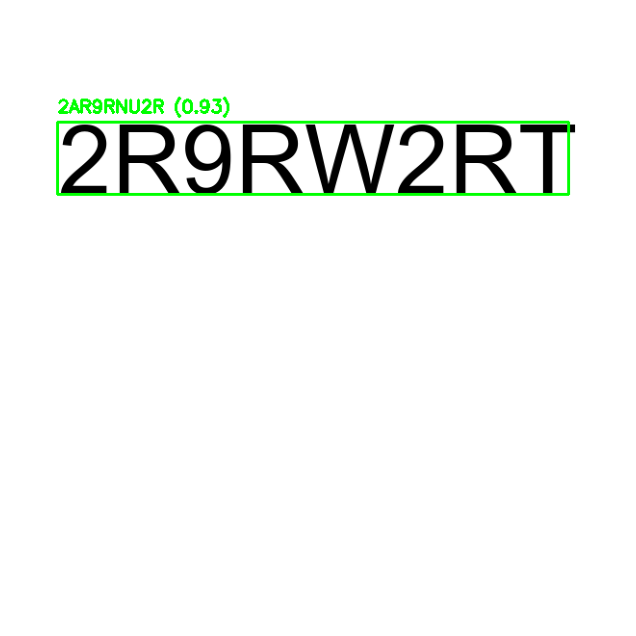

In [6]:
# pipeline.py

import torch
import torchvision.transforms as transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. ЗАГРУЗКА YOLO (детектор)
# ============================================
from ultralytics import YOLO

detector = YOLO("runs/best6_detect.pt")  # твоя обученная модель

# ============================================
# 2. ЗАГРУЗКА CRNN (распознаватель)
# ============================================

CHARS = 'ABCDEFGHJKLMNPQRSTUVWXYZ23456789'  # твои символы
NUM_CLASSES = len(CHARS) + 1  # +1 для blank

recognizer = CRNN(num_classes=NUM_CLASSES)
recognizer.load_state_dict(torch.load('runs/best10.pt', map_location='cpu'))
recognizer.eval()

# Преобразования для CRNN
transform = transforms.Compose([
    transforms.Resize((60, 160)),  # твои размеры капчи
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# ============================================
# 3. ФУНКЦИЯ ДЛЯ РАСПОЗНАВАНИЯ ОДНОЙ КАРТИНКИ
# ============================================
def decode_prediction(logits, chars):
    """CTC декодирование"""
    preds = torch.argmax(logits, dim=2)
    preds = preds.cpu().numpy()[0]

    text = []
    prev = 0
    for idx in preds:
        if idx != 0 and idx != prev:
            text.append(chars[idx - 1])
        prev = idx
    return ''.join(text)


def recognize_text(image_crop):
    """
    Распознаёт текст на вырезанной области
    image_crop: PIL Image или numpy array (RGB или BGR)
    """
    # Конвертируем в ч/б
    if isinstance(image_crop, np.ndarray):
        image_crop = Image.fromarray(cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB))

    image_crop = image_crop.convert('L')  # в ч/б

    # Преобразуем для модели
    img_tensor = transform(image_crop).unsqueeze(0)

    with torch.no_grad():
        logits = recognizer(img_tensor)
        text = decode_prediction(logits, CHARS)

    return text


# ============================================
# 4. ФУНКЦИЯ ДЛЯ ВСЕГО ИЗОБРАЖЕНИЯ
# ============================================
def detect_and_recognize(image_path, conf_threshold=0.25):
    """
    Принимает: путь к изображению
    Возвращает: список результатов [{'bbox': [x1,y1,x2,y2], 'text': 'ABC', 'confidence': 0.95}, ...]
    """
    # Детекция YOLO
    results = detector(image_path, conf=conf_threshold)

    detections = []

    for result in results:
        boxes = result.boxes
        if boxes is not None:
            # Загружаем оригинальное изображение для вырезания
            img_original = cv2.imread(image_path)

            for box in boxes:
                # Координаты bounding box
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                conf = float(box.conf[0].cpu().numpy())

                # Вырезаем область
                crop = img_original[y1:y2, x1:x2]

                # Распознаём текст
                if crop.size > 0:
                    text = recognize_text(crop)
                else:
                    text = ""

                detections.append({
                    'bbox': [x1, y1, x2, y2],
                    'text': text,
                    'confidence': conf
                })

    return detections


# ============================================
# 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================
def visualize_results(image_path, detections):
    """Рисует bounding box'ы и текст на изображении"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        text = det['text']
        conf = det['confidence']

        # Рисуем прямоугольник
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Пишем текст
        label = f"{text} ({conf:.2f})"
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    return img


# ============================================
# 6. ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================
if __name__ == '__main__':
    # Запускаем на тестовом изображении
    image_path = 'dt/captcha/2R9RW2RT.png'  # поменяй на свой путь
    # image_path = 'test.png'  # поменяй на свой путь

    # Детектируем и распознаём
    detections = detect_and_recognize(image_path)

    # Выводим результаты
    print("Результаты:")
    for i, det in enumerate(detections):
        print(f"  {i + 1}. Текст: '{det['text']}' | Уверенность: {det['confidence']:.2f} | Bbox: {det['bbox']}")

    # Показываем визуализацию
    visualize_results(image_path, detections)